# Grad-CAM & Intermediate Feature Maps

Notebook ini berisi dua teknik visualisasi untuk melihat cara kerja dari model CNN terbaik (arsitektur Conv2D dengan shared parameter):
1. **Intermediate Feature Maps**: Berguna untuk melihat secara langsung hasil ekstraksi fitur (aktivasi) di setiap layer konvolusi.
2. **Grad-CAM (Gradient-weighted Class Activation Mapping)**: Digunakan untuk mencari tahu area spesifik di dalam gambar yang paling dipertimbangkan oleh model saat membuat keputusan klasifikasi.

In [1]:
import os, sys, glob, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

def _find_root(marker="requirements.txt"):
    p = Path(os.getcwd())
    while p != p.parent:
        if (p / marker).exists():
            return p
        p = p.parent
    raise RuntimeError("Repo root tidak ketemu.")

REPO_ROOT = _find_root()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))

import tensorflow as tf
from tensorflow import keras
from cnn.train_keras import build_conv2d_model, IMG_SIZE
from bonus.gradcam import get_intermediate_feature_maps, grad_cam, overlay_heatmap
from shared.image_utils import load_image
print("Root:", REPO_ROOT)

Root: c:\Users\kefas\OneDrive\Documents\Coding\ITB\SMT6\MachineLearning\tubes-2\CNN-RNN-digaspolndangakndangak


## Config

In [ ]:
MODELS_DIR   = "models/cnn"
TEST_DIR     = "data/intel/seg_test/seg_test"
BEST_MODEL   = "cnn-3L-large-k3-max"
NUM_SAMPLES  = 10

CLASSES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

FILTER_CONFIGS = {
    "base":  {2: [32, 64],       3: [32, 64, 128]},
    "large": {2: [64, 128],      3: [64, 128, 256]},
}
parts = BEST_MODEL.split("-")
n_layers, f_type, k_size, p_type = int(parts[1][0]), parts[2], int(parts[3][1:]), parts[4]

## Load Model & Sampel Gambar

In [3]:
model = build_conv2d_model(
    num_conv_layers=n_layers,
    filters=FILTER_CONFIGS[f_type][n_layers],
    kernel_sizes=[k_size] * n_layers,
    pooling=p_type,
)
model.load_weights(os.path.join(MODELS_DIR, f"{BEST_MODEL}.keras"))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,486 (1.54 MB)

 Trainable params: 404,486 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
conv_layer_names = [l.name for l in model.layers if "conv2d" in l.name.lower()]
last_conv_name   = conv_layer_names[-1]
print("Conv layers :", conv_layer_names)
print("Last conv   :", last_conv_name)

Conv layers : ['conv2d', 'conv2d_1', 'conv2d_2']
Last conv   : conv2d_2


In [ ]:
random.seed(42)
sample_paths, sample_labels = [], []

for cls_idx, cls_name in enumerate(CLASSES):
    cls_dir = os.path.join(TEST_DIR, cls_name)
    if not os.path.isdir(cls_dir):
        continue
    all_imgs = sorted(glob.glob(os.path.join(cls_dir, "*.jpg")))
    chosen = random.sample(all_imgs, min(2, len(all_imgs)))
    for p in chosen:
        sample_paths.append(p)
        sample_labels.append(cls_idx)

sample_paths = sample_paths[:NUM_SAMPLES]
sample_labels = sample_labels[:NUM_SAMPLES]
print(f"Loaded {len(sample_paths)} sample images")

# Load dan normalisasi gambar
sample_images = [load_image(p, target_size=IMG_SIZE) for p in sample_paths]

Loaded 10 sample images


## 1. Intermediate Feature Maps

In [6]:
# Visualisasi feature maps untuk 1 contoh gambar (gambar pertama)
IMG_IDX = 0
img_sample = sample_images[IMG_IDX]
true_label = CLASSES[sample_labels[IMG_IDX]]

# Prediksi Keras untuk referensi
img_batch = np.expand_dims(img_sample, 0)
pred_probs = model.predict(img_batch, verbose=0)[0]
pred_label = CLASSES[np.argmax(pred_probs)]
print(f"Gambar: {os.path.basename(sample_paths[IMG_IDX])}")
print(f"Ground Truth: {true_label} | Prediksi: {pred_label} ({pred_probs.max():.2%})")

Gambar: 23188.jpg
Ground Truth: buildings | Prediksi: buildings (97.65%)


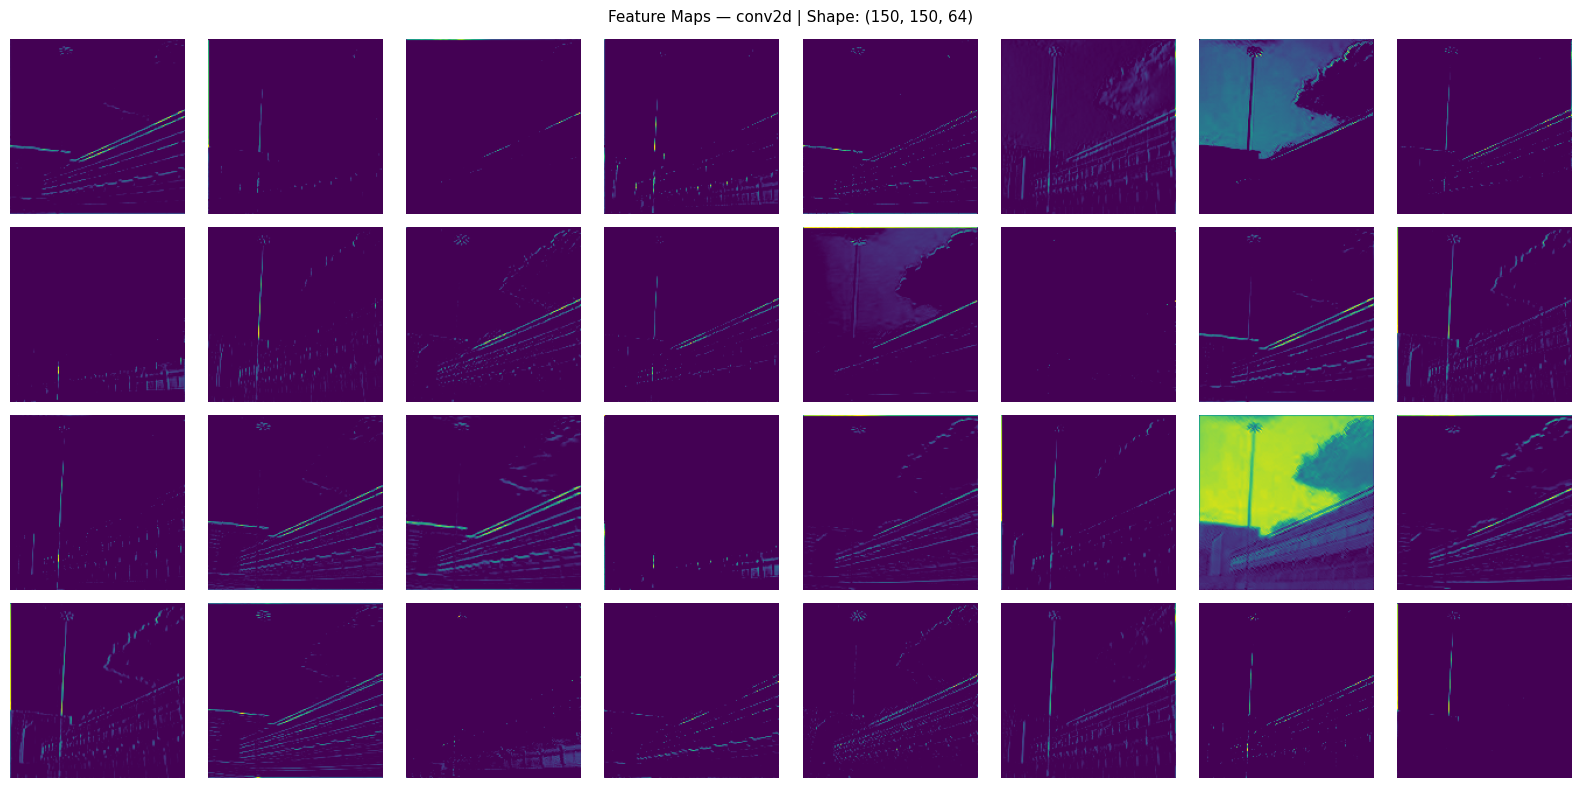

  conv2d: shape=(150, 150, 64), max=1.070, mean=0.011


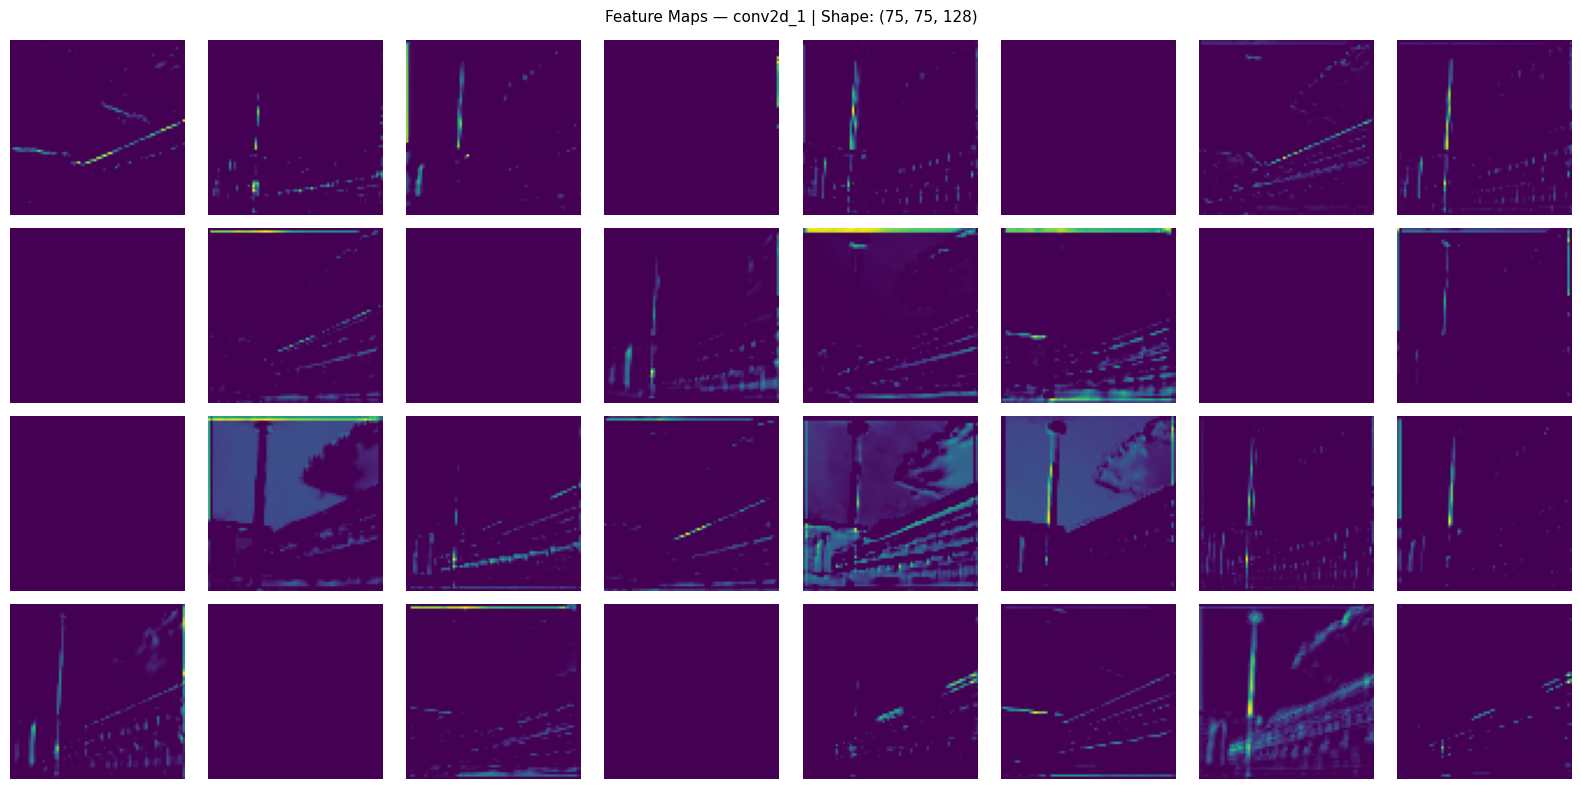

  conv2d_1: shape=(75, 75, 128), max=4.295, mean=0.035


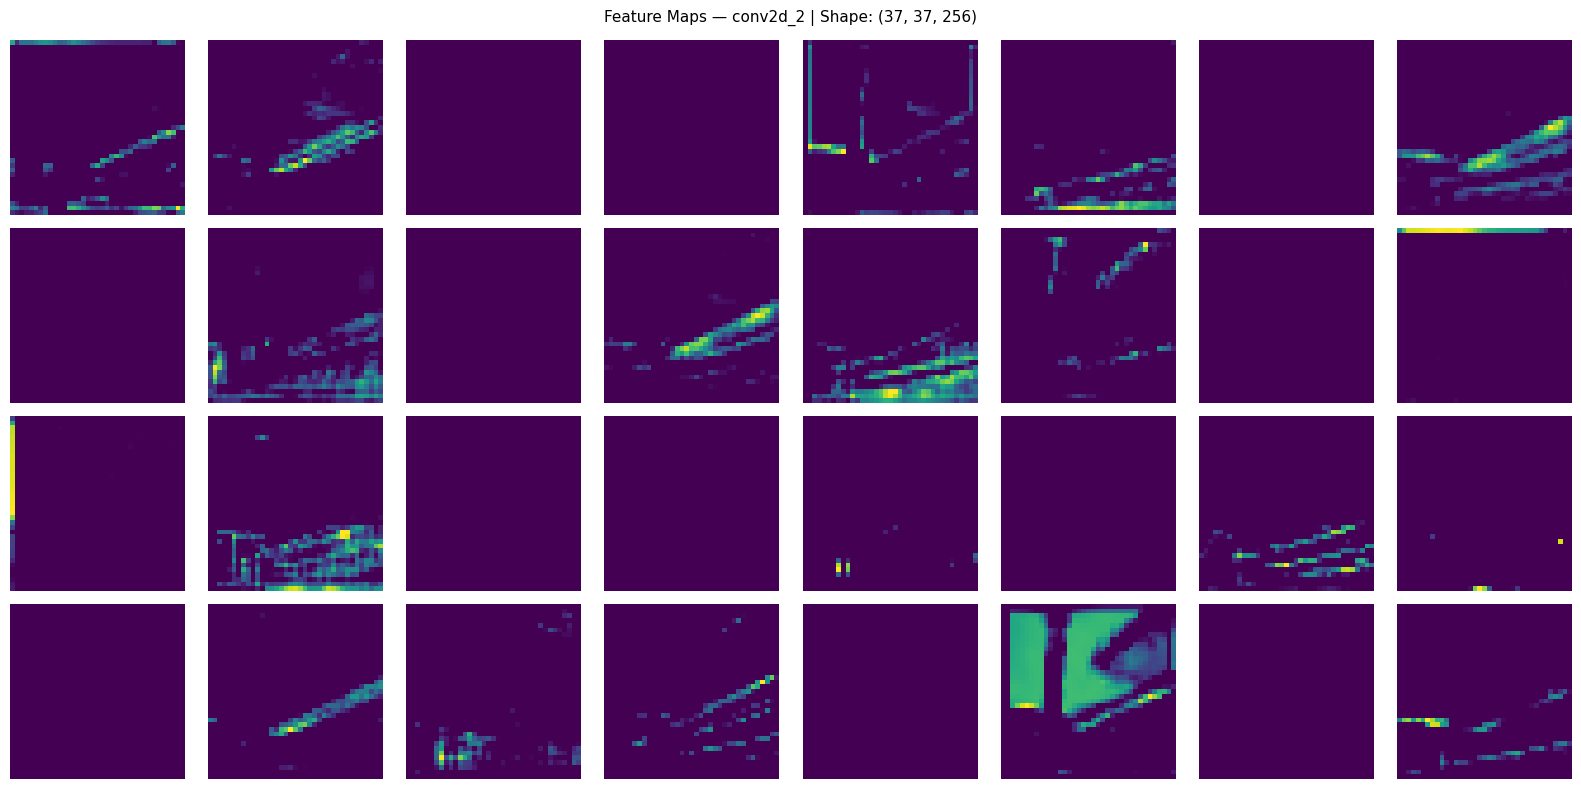

  conv2d_2: shape=(37, 37, 256), max=24.098, mean=0.100


In [ ]:
# Ekstrak feature maps untuk setiap layer konvolusi
feature_maps = get_intermediate_feature_maps(model, img_sample, conv_layer_names)

for layer_name in conv_layer_names:
    fmap = feature_maps[layer_name]  # (H, W, C)
    n_filters = fmap.shape[-1]
    n_cols = 8
    n_rows = min(4, n_filters // n_cols + 1)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
    axes = axes.flatten()
    
    for i in range(n_rows * n_cols):
        ax = axes[i]
        if i < n_filters:
            ax.imshow(fmap[:, :, i], cmap="viridis")
        ax.axis("off")
    
    fig.suptitle(f"Feature Maps — {layer_name} | Shape: {fmap.shape}", fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, f"feature_maps_{layer_name}.png"), dpi=100)
    plt.show()
    print(f"  {layer_name}: shape={fmap.shape}, max={fmap.max():.3f}, mean={fmap.mean():.3f}")

## 2. Grad-CAM — 10 Contoh Gambar

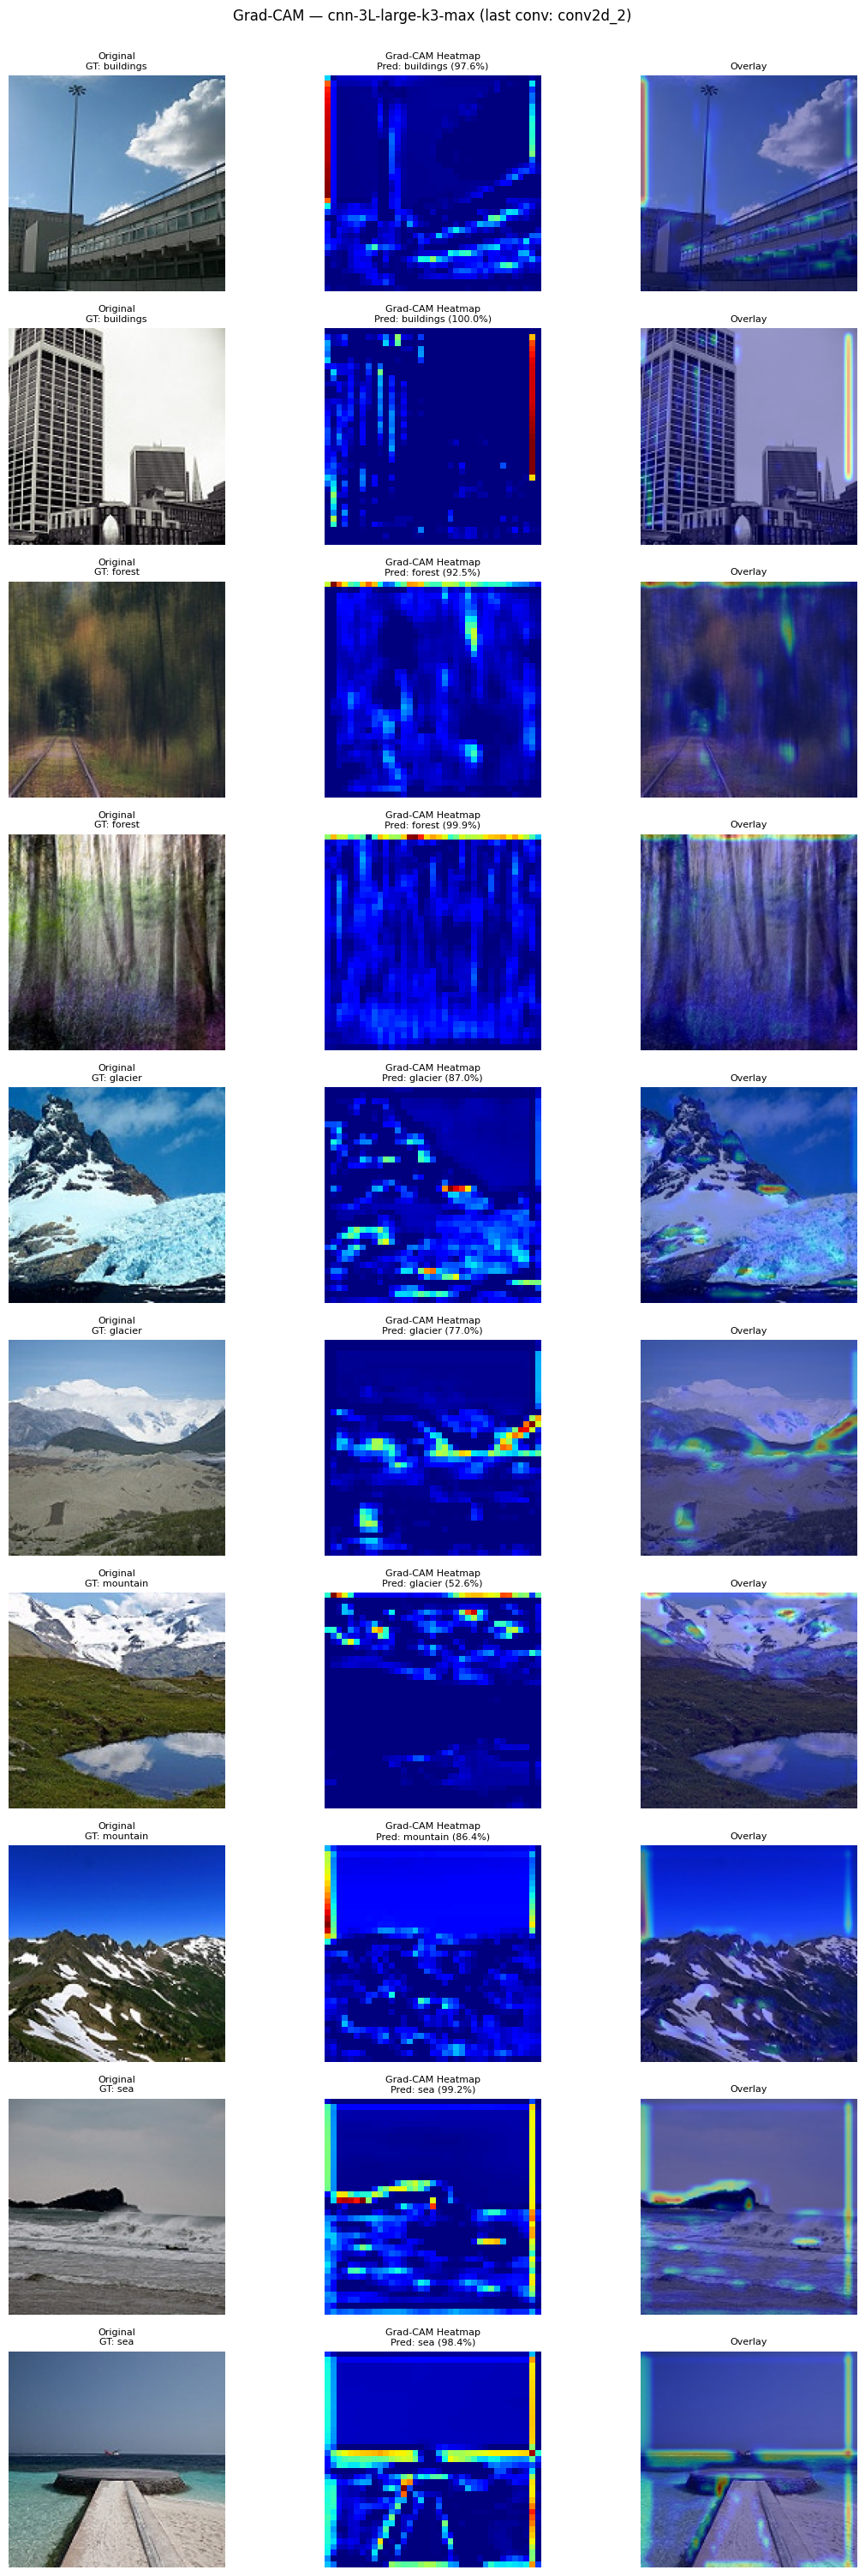

In [8]:
fig, axes = plt.subplots(NUM_SAMPLES, 3, figsize=(12, NUM_SAMPLES * 3))

for row, (img_path, img, true_idx) in enumerate(zip(sample_paths, sample_images, sample_labels)):
    img_batch = np.expand_dims(img, 0)
    pred_probs = model.predict(img_batch, verbose=0)[0]
    pred_idx   = int(np.argmax(pred_probs))

    heatmap    = grad_cam(model, img, pred_idx, last_conv_name)
    superimposed = overlay_heatmap(img, heatmap, alpha=0.4)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Original\nGT: {CLASSES[true_idx]}", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heatmap, cmap="jet")
    axes[row, 1].set_title(f"Grad-CAM Heatmap\nPred: {CLASSES[pred_idx]} ({pred_probs[pred_idx]:.1%})", fontsize=8)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(superimposed)
    axes[row, 2].set_title("Overlay", fontsize=8)
    axes[row, 2].axis("off")

plt.suptitle(f"Grad-CAM — {BEST_MODEL} (last conv: {last_conv_name})", fontsize=12, y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, "gradcam_results.png"), dpi=100, bbox_inches="tight")
plt.show()

## 3. Grad-CAM per Kelas (Analisis Setiap Kategori)

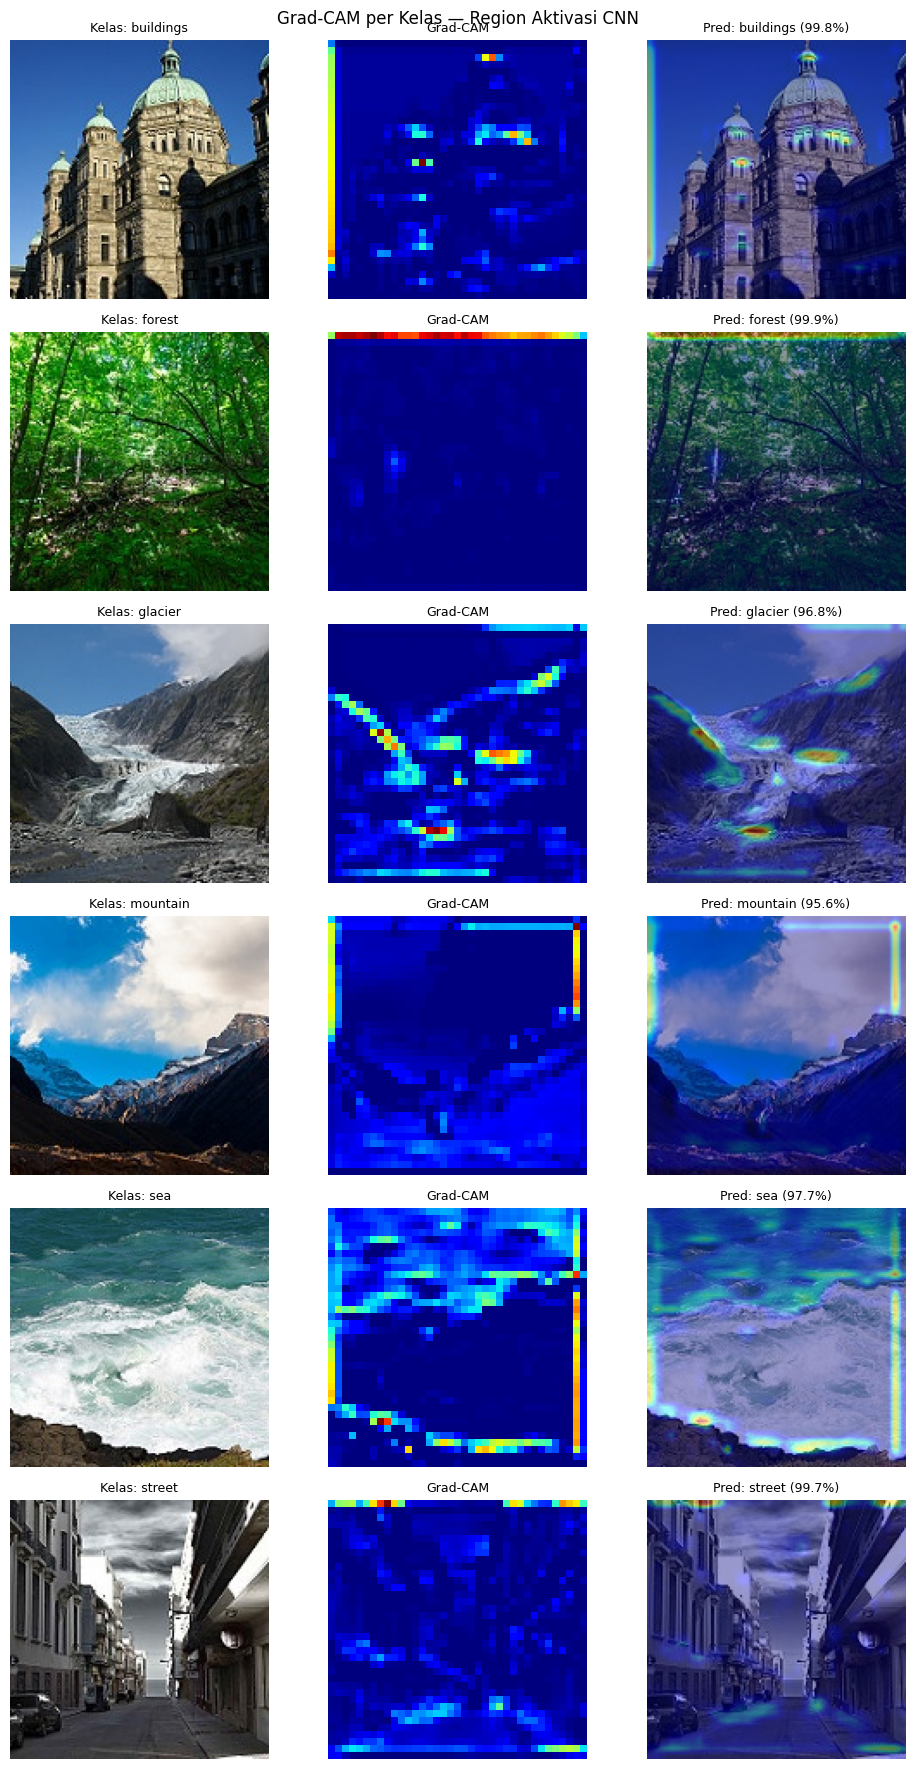

In [ ]:
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(10, len(CLASSES) * 3))

for row, cls_name in enumerate(CLASSES):
    cls_dir = os.path.join(TEST_DIR, cls_name)
    if not os.path.isdir(cls_dir):
        continue

    all_imgs = sorted(glob.glob(os.path.join(cls_dir, "*.jpg")))
    random.shuffle(all_imgs)
    
    found = False
    for img_path in all_imgs[:20]:
        img = load_image(img_path, target_size=IMG_SIZE)
        img_batch = np.expand_dims(img, 0)
        pred_probs = model.predict(img_batch, verbose=0)[0]
        pred_idx = int(np.argmax(pred_probs))
        if CLASSES[pred_idx] == cls_name:
            found = True
            break
    
    if not found:
        img = load_image(all_imgs[0], target_size=IMG_SIZE)
        pred_probs = model.predict(np.expand_dims(img, 0), verbose=0)[0]
        pred_idx = int(np.argmax(pred_probs))
    
    heatmap = grad_cam(model, img, pred_idx, last_conv_name)
    superimposed = overlay_heatmap(img, heatmap, alpha=0.4)
    
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Kelas: {cls_name}", fontsize=9)
    axes[row, 0].axis("off")
    
    axes[row, 1].imshow(heatmap, cmap="jet")
    axes[row, 1].set_title(f"Grad-CAM", fontsize=9)
    axes[row, 1].axis("off")
    
    axes[row, 2].imshow(superimposed)
    axes[row, 2].set_title(f"Pred: {CLASSES[pred_idx]} ({pred_probs[pred_idx]:.1%})", fontsize=9)
    axes[row, 2].axis("off")

plt.suptitle("Grad-CAM per Kelas — Region Aktivasi CNN", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, "gradcam_per_class.png"), dpi=100, bbox_inches="tight")
plt.show()

## Analisis & Kesimpulan

Berdasarkan hasil visualisasi Feature Maps dan Grad-CAM di atas, terdapat beberapa pola menarik yang dapat disimpulkan tentang bagaimana cara model CNN melihat dan menginterpretasikan gambar, yaitu:

**1. Transformasi Fitur di Tiap Layer (Intermediate Feature Maps)**
Dapat dilihat kalau layer konvolusi pertama conv2d masih menangkap bentuk dasar gambar dengan cukup jelas dan kasat mata, seperti tepi bangunan atau garis batas jalan. Akan tetapi semakin dalam layernya (misalnya di conv2d_2), kumpulan feature map-nya menjadi semakin abstrak dan susah untuk dikenali oleh mata manusia. Hal ini sangat wajar, karena di layer-layer terdalam, model tidak lagi mencari garis atau warna, melainkan mengekstrak high level features yang sangat spesifik untuk keperluan klasifikasi.

**2. Fokus Perhatian Model (Analisis Grad-CAM)**
Hasil Grad-CAM juga menunjukkan bahwa model sudah belajar mengenali objek utama yang tepat, tidak hanya menebak asal dari warna dasar atau menghafal background, dimana untuk setiap kategori:
*   Buildings: Aktivasi terkuatnya cenderung terkonsentrasi di bagian sudut, pola jendela, atau tepi bangunan yang tegas.
*   Forest: Model ini sangat sensitif terhadap tekstur dari kumpulan dedaunan.
*   Glacier: Heatmapnya berkumpul secara solid di area bongkahan es.
*   Mountain: Model lebih fokus ke siluet puncak gunung yang tajam atau area bebatuan kasar.
*   Sea: Model cenderung melihat garis air yang memisahkannya dengan langit.
*   Street: Aktivasi tertingginya hampir selalu di garis-garis aspal atau sisi jalanan.

**Kesimpulan Akhir**
Uji visualisasi ini membuat kita lebih yakin dan paham terhadap model cnn-3L-large yang telah dilatih. Model yang dibangun terbukti berjalan sesuai teori dan telah berhasil memahami karakteristik unik dari tiap kelas pada dataset Intel Image Classification.
